# Modeling of a tunnel diode circuit
Hassan K. Khalil, Nonlinear Systems, section 1.2.2 

## Mathematical model

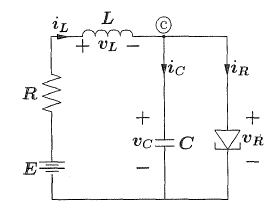

$$
\dot{x}_1 = \frac{1}{C}\left(-h(x_1) + x_2 \right),
$$
$$
\dot{x}_2 = \frac{1}{L}\left(-x_1-Rx_2 + u \right),
$$
where $x_1=\upsilon_C$, $x_2 = i_L$, $h(x_1) = 17.76x_1-103.79x_1^2+229.62x_1^3-226.31x_1^4+83.72x_1^5$

State Space model
$$
\dot{x} = Ax + Bu + Fh(x_1)
$$

## State-space modeling

In [1]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Parameters
Cap = 2 #Capacity
L = 5
R = 1.5

# State-space matrices
A = np.array([[0, 1/Cap],
              [-1/L, -R/L]])
B = np.array([[0],
              [1/L]])
F = np.array([[-1/Cap],
              [0]])

In [3]:
def nonlinearity(x1):
    return np.array(17.76*x1 +-103.79*np.power(x1, 2) + 229.62*np.power(x1, 3) - 226.31*np.power(x1, 4) + 83.72*np.power(x1, 5)).reshape(-1, 1)

In [4]:
def diode_model(t, x, time_points, u_list):
    u = np.interp(t, time_points, u_list).reshape(-1, 1)
    dxdt = np.matmul(A, x.reshape(-1, 1)) + np.matmul(B, u)
    nonlin =  nonlinearity(x[0])
    dxdt += np.matmul(F, nonlin)
    return dxdt.ravel()

In [5]:
startTime=0
endTime=20
timeSteps=10000
simulationTime=np.linspace(startTime,endTime,timeSteps)

u_list = [1.2] *timeSteps
x0 = np.array([0, 0])

In [6]:
sol = solve_ivp(diode_model, t_span=[startTime, endTime], 
                t_eval=simulationTime, 
                y0=x0.ravel(), method='RK45', args=(simulationTime, u_list))
state = sol.y

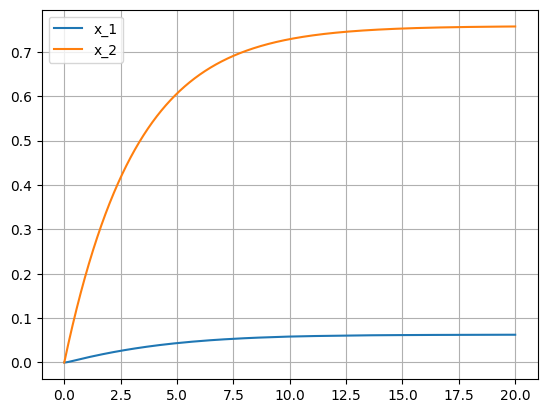

In [7]:
plt.plot(simulationTime, state[0, :], label='x_1')
plt.plot(simulationTime, state[1, :], label='x_2')
plt.grid()
plt.legend()